# Rootzone Soft-Sensor


In [1]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.metrics import r2_score
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import HuberRegressor
import matplotlib.pyplot as plt

df = pd.read_csv('master.csv', parse_dates=['timestamp'])
df = df.sort_values('timestamp').set_index('timestamp')
for c in df.columns:
    df[c] = pd.to_numeric(df[c], errors='coerce')
master_df = df.copy().sort_index()

n_ph = int(master_df['ph'].notna().sum()) if 'ph' in master_df.columns else 0
n_ec = int(master_df['ec_ms'].notna().sum()) if 'ec_ms' in master_df.columns else 0
n_both = int((master_df['ph'].notna() & master_df['ec_ms'].notna()).sum()) if {'ph','ec_ms'}.issubset(master_df.columns) else 0

print(f'Loaded: {len(df)} rows')
print(f'Labeled samples -> pH: {n_ph}, EC: {n_ec}, both: {n_both}')

ACID_FERTS = ['Phosphoric acid[mg]-H3PO4']
SALT_FERTS = ['Monopotassium Phosphate[mg] -KH2PO4', 'Potassium Chloride[mg] - KCL',
              'Kortin [mg]', 'Ammonium Nitrate [mg] -NH4NO3', 'Gypsum - CaSO4*2H2O [mg]']
CORE_SALT_FERTS = ['Monopotassium Phosphate[mg] -KH2PO4', 'Potassium Chloride[mg] - KCL',
                   'Ammonium Nitrate [mg] -NH4NO3']
EC_COMPONENT_COLS = {
    'salt_kh2po4': 'Monopotassium Phosphate[mg] -KH2PO4',
    'salt_kcl': 'Potassium Chloride[mg] - KCL',
    'salt_kortin': 'Kortin [mg]',
    'salt_nh4no3': 'Ammonium Nitrate [mg] -NH4NO3',
    'salt_gypsum': 'Gypsum - CaSO4*2H2O [mg]',
}

def _to_num(s, d=0.0): return pd.to_numeric(s, errors='coerce').fillna(d)

def _sum_avail(fr, cols):
    u = [c for c in cols if c in fr.columns]
    return float(fr[u].apply(pd.to_numeric, errors='coerce').fillna(0).sum().sum()) if u else 0.0

def _sum_avail_series(fr, cols):
    u = [c for c in cols if c in fr.columns]
    return fr[u].apply(pd.to_numeric, errors='coerce').fillna(0).sum(axis=1) if u else pd.Series(0.0, index=fr.index)

def _get_fert_any(fr):
    if 'fertilization_flag' in fr.columns: return _to_num(fr['fertilization_flag'])
    a = 'fertilization_type_a_flag' in fr.columns
    b = 'fertilization_type_b_flag' in fr.columns
    if a or b:
        fa = _to_num(fr['fertilization_type_a_flag']) if a else pd.Series(0., index=fr.index)
        fb = _to_num(fr['fertilization_type_b_flag']) if b else pd.Series(0., index=fr.index)
        return ((fa > 0) | (fb > 0)).astype(float)
    return pd.Series(0., index=fr.index)


Loaded: 16682 rows
Labeled samples -> pH: 109, EC: 109, both: 109


In [2]:
def get_features_for_row(master_df, anchor_idx, current_idx):
    t0 = pd.Timestamp(anchor_idx)
    t1 = pd.Timestamp(current_idx)
    ph0 = float(master_df.loc[t0, 'ph'])
    ec0 = float(master_df.loc[t0, 'ec_ms'])
    gap_h = float((t1 - t0).total_seconds() / 3600.0)
    safe_gap_h = max(gap_h, 0.16)

    seg = master_df.loc[(master_df.index >= t0) & (master_df.index < t1)]

    fert_acid_total = _sum_avail(seg, ACID_FERTS)
    fert_salt_total = _sum_avail(seg, SALT_FERTS)
    fert_total = fert_acid_total + fert_salt_total
    irr_total = float(_to_num(seg['irrigation_ml_current']).sum()) if 'irrigation_ml_current' in seg.columns else 0.0

    fert_acid_s = _sum_avail_series(seg, ACID_FERTS)
    fert_salt_s = _sum_avail_series(seg, SALT_FERTS)
    fert_total_s = fert_acid_s + fert_salt_s
    irr_s = _to_num(seg['irrigation_ml_current']) if 'irrigation_ml_current' in seg.columns else pd.Series(0.0, index=seg.index)

    time_to_t1_hours = (t1 - seg.index).total_seconds() / 3600.0 if len(seg) else np.array([])
    decay_lambda = 0.34
    weights = np.exp(-decay_lambda * time_to_t1_hours) if len(seg) else np.array([])

    weighted_irr = float((irr_s * weights).sum()) if len(seg) else 0.0
    weighted_fert_acid = float((fert_acid_s * weights).sum()) if len(seg) else 0.0
    weighted_fert_salt = float((fert_salt_s * weights).sum()) if len(seg) else 0.0
    weighted_total_fert = float((fert_total_s * weights).sum()) if len(seg) else 0.0

    fert_conc = float(fert_total / (irr_total + 1.0))
    fert_concentration = float(np.clip(fert_total / (irr_total + 1.0), 0, 1e4))
    salt_balance = float(fert_salt_total - irr_total)

    ET0_sum = float(_to_num(seg['ET0']).sum()) if 'ET0' in seg.columns else 0.0
    ET0_per_hour = float(ET0_sum / safe_gap_h)
    leaching_fraction = float(np.clip(irr_total / (ET0_sum + 1e-3), 0, 100))

    log_ec_drive = float(np.log(fert_conc + 0.01) - np.log(ec0 + 0.01))
    ph_drive = float(fert_total / (ph0 + 1e-3))

    H3PO4_COL = 'Phosphoric acid[mg]-H3PO4'
    h3po4_total = float(_to_num(seg[H3PO4_COL]).sum()) if H3PO4_COL in seg.columns else 0.0
    acid_rate = float(fert_acid_total / safe_gap_h)
    ph_buffer_ratio = float(fert_acid_total / (ec0 + 0.1))
    soil_temp_sq = float(_to_num(seg['soil_temp_pred']).mean() ** 2) if 'soil_temp_pred' in seg.columns and len(seg) > 0 else 0.0

    if 'internal_air_temp_c' in seg.columns and 'internal_rh_%' in seg.columns and len(seg) > 0:
        ts = _to_num(seg['internal_air_temp_c'])
        rhs = _to_num(seg['internal_rh_%'])
        ess = 0.6108 * np.exp((17.27 * ts) / (ts + 237.3))
        vpds = ess * (1. - rhs / 100.)
        vpd_mean = float(vpds.mean())
    else:
        vpd_mean = 0.0

    soil_temp_mean = float(_to_num(seg['soil_temp_pred']).mean()) if 'soil_temp_pred' in seg.columns and len(seg) > 0 else 0.0
    canopy = float(_to_num(seg['canopy_cover']).mean()) if 'canopy_cover' in seg.columns and len(seg) > 0 else 0.0
    transpiration_pull = float(vpd_mean * canopy)
    evapo_concentration = float(ET0_sum * canopy)

    temp_s = _to_num(seg['internal_air_temp_c']) if 'internal_air_temp_c' in seg.columns else pd.Series(dtype=float)
    if len(temp_s) > 1:
        temp_trend = float(temp_s.iloc[-1] - temp_s.iloc[0])
        temp_range = float(temp_s.max() - temp_s.min())
    else:
        temp_trend = 0.0
        temp_range = 0.0

    rad_s = _to_num(seg['internal_radiation']) if 'internal_radiation' in seg.columns else pd.Series(dtype=float)
    rad_max = float(rad_s.max()) if len(rad_s) > 0 else 0.0
    daylight_proportion = float((rad_s > 10).sum() / 6.0 / safe_gap_h) if len(rad_s) > 0 else 0.0

    rad_integral = float(rad_s.sum() * (10.0 / 60.0)) if len(rad_s) > 0 else 0.0
    ph_deviation = float(ph0 - 6.5)
    photo_temp_interaction = float(vpd_mean * soil_temp_mean)

    if 'irrigation_ml_current' in seg.columns and len(seg) > 0:
        ie = _to_num(seg['irrigation_ml_current'])
        ii = ie[ie > 0].index
        hrs_since_irr = float((t1 - ii.max()).total_seconds() / 3600.) if len(ii) > 0 else gap_h
    else:
        hrs_since_irr = gap_h

    fser = _get_fert_any(seg) if len(seg) > 0 else pd.Series(dtype=float)
    fi2 = fser[fser > 0].index
    hrs_since_fert = float((t1 - fi2.max()).total_seconds() / 3600.) if len(fi2) > 0 else gap_h

    acid_dilution = float(fert_acid_total / (irr_total + fert_total + 1.0))
    buffered_acid_pressure = float(weighted_fert_acid / ((weighted_irr + 1.0) * (ec0 + 0.1)))
    canopy_et0 = float(canopy * ET0_sum)
    salt_stress_index = float(hrs_since_irr * ec0)

    rad_x_canopy = float(rad_s.mean() * canopy) if len(rad_s) > 0 else 0.0
    temp_x_canopy = float(soil_temp_mean * canopy)

    hour_a = t0.hour + t0.minute / 60.0
    hour_b = t1.hour + t1.minute / 60.0

    component_totals = {
        key: float(_to_num(seg[col]).sum()) if col in seg.columns else 0.0
        for key, col in EC_COMPONENT_COLS.items()
    }
    salt_conc_t0_t1 = float(fert_salt_total / (irr_total + 1.0))
    acid_conc_t0_t1 = float(fert_acid_total / (irr_total + 1.0))
    weighted_salt_conc = float(weighted_fert_salt / (weighted_irr + 1.0))
    weighted_total_conc = float(weighted_total_fert / (weighted_irr + 1.0))
    salt_per_hour = float(fert_salt_total / safe_gap_h)
    irr_per_hour = float(irr_total / safe_gap_h)
    salt_to_et0 = float(fert_salt_total / (ET0_sum + 0.1))
    irr_to_et0 = float(irr_total / (ET0_sum + 0.1))
    overnight_fraction = float((_to_num(seg['internal_radiation']) <= 10).sum() / 6.0 / safe_gap_h) \
        if len(seg) > 0 and 'internal_radiation' in seg.columns else 0.0
    salt_x_daylight = float(fert_salt_total * daylight_proportion)
    days_after_planting_t0 = float(master_df.loc[t0, 'days_after_planting']) \
        if 'days_after_planting' in master_df.columns else 0.0
    days_after_planting_t1 = float(master_df.loc[t1, 'days_after_planting']) \
        if 'days_after_planting' in master_df.columns else days_after_planting_t0
    canopy_t1 = float(master_df.loc[t1, 'canopy_cover']) if 'canopy_cover' in master_df.columns else canopy
    stage_x_salt_conc = float((days_after_planting_t1 / 100.0) * salt_conc_t0_t1)
    ec_regime_low = float(ec0 <= 0.5)
    ec_regime_mid = float((ec0 > 0.5) and (ec0 <= 1.5))
    ec_regime_high = float((ec0 > 1.5) and (ec0 <= 3.0))
    ec_regime_very_high = float(ec0 > 3.0)
    fertigation_event = float(fert_salt_total > 0)
    low_dilution_event = float(irr_total <= 300.0)
    salt_shock_event = float((fert_salt_total >= 325.0) and (irr_total <= 300.0))
    super_shock_event = float((fert_salt_total >= 900.0) and (irr_total <= 400.0))
    ec_gap_interaction = float(ec0 * gap_h)
    ec_log_anchor = float(np.log(ec0 + 0.05))
    recent_6h = seg.loc[seg.index >= t1 - pd.Timedelta(hours=6)] if len(seg) > 0 else seg
    salt_recent_6h = float(_sum_avail(recent_6h, SALT_FERTS)) if len(recent_6h) > 0 else 0.0
    core_salt_s = _sum_avail_series(seg, CORE_SALT_FERTS) if len(seg) > 0 else pd.Series(0.0, index=seg.index)
    salt_event_idx = core_salt_s[core_salt_s > 0].index.max() if len(core_salt_s[core_salt_s > 0]) else None
    irr_event_idx = irr_s[irr_s > 0].index.max() if len(irr_s[irr_s > 0]) else None
    last_salt_dose = float(core_salt_s.loc[salt_event_idx]) if salt_event_idx is not None else 0.0
    last_irr_amount = float(irr_s.loc[salt_event_idx]) if salt_event_idx is not None and salt_event_idx in irr_s.index else 0.0
    hrs_since_last_salt_event = float((t1 - salt_event_idx).total_seconds() / 3600.0) if salt_event_idx is not None else gap_h
    last_event_salt_conc = float(last_salt_dose / (last_irr_amount + 1.0))
    irr_after_last_salt = float(_to_num(seg.loc[seg.index > salt_event_idx, 'irrigation_ml_current']).sum()) \
        if salt_event_idx is not None and 'irrigation_ml_current' in seg.columns else 0.0

    return {
        'ph0': ph0,
        'ec0': ec0,
        'gap_hours': gap_h,

        'irr_total_t0_t1': irr_total,
        'fert_total_t0_t1': fert_total,
        'fert_salt_total_t0_t1': fert_salt_total,
        'salt_balance_t0_t1': salt_balance,
        'ET0_sum_t0_t1': ET0_sum,

        'weighted_irr': weighted_irr,
        'weighted_total_fert': weighted_total_fert,
        'weighted_fert_acid': weighted_fert_acid,
        'weighted_fert_salt': weighted_fert_salt,

        'fert_conc': fert_conc,
        'fert_concentration': fert_concentration,
        'log_ec_drive': log_ec_drive,
        'ph_drive': ph_drive,
        'leaching_fraction': leaching_fraction,
        'ET0_per_hour': ET0_per_hour,

        'acid_rate': acid_rate,
        'ph_buffer_ratio': ph_buffer_ratio,
        'soil_temp_sq': soil_temp_sq,

        'rad_integral': rad_integral,
        'ph_deviation': ph_deviation,
        'photo_temp_interaction': photo_temp_interaction,

        'acid_dilution': acid_dilution,
        'buffered_acid_pressure': buffered_acid_pressure,
        'canopy_et0': canopy_et0,
        'salt_stress_index': salt_stress_index,

        'rad_x_canopy': rad_x_canopy,
        'temp_x_canopy': temp_x_canopy,

        'vpd_mean': vpd_mean,
        'soil_temp_mean': soil_temp_mean,
        'soil_temp_t0': soil_temp_mean,  # alias: soil temp at anchor point
        'canopy': canopy,
        'transpiration_pull': transpiration_pull,
        'evapo_concentration': evapo_concentration,

        'h3po4_total': h3po4_total,
        **component_totals,
        'salt_conc_t0_t1': salt_conc_t0_t1,
        'acid_conc_t0_t1': acid_conc_t0_t1,
        'weighted_salt_conc': weighted_salt_conc,
        'weighted_total_conc': weighted_total_conc,
        'salt_per_hour': salt_per_hour,
        'irr_per_hour': irr_per_hour,
        'salt_to_et0': salt_to_et0,
        'irr_to_et0': irr_to_et0,
        'salt_x_daylight': salt_x_daylight,
        'overnight_fraction': overnight_fraction,
        'days_after_planting_t0': days_after_planting_t0,
        'days_after_planting_t1': days_after_planting_t1,
        'canopy_t1': canopy_t1,
        'stage_x_salt_conc': stage_x_salt_conc,
        'ec_regime_low': ec_regime_low,
        'ec_regime_mid': ec_regime_mid,
        'ec_regime_high': ec_regime_high,
        'ec_regime_very_high': ec_regime_very_high,
        'fertigation_event': fertigation_event,
        'low_dilution_event': low_dilution_event,
        'salt_shock_event': salt_shock_event,
        'super_shock_event': super_shock_event,
        'ec_gap_interaction': ec_gap_interaction,
        'ec_log_anchor': ec_log_anchor,
        'hrs_since_irr': hrs_since_irr,
        'hrs_since_fert': hrs_since_fert,
        'temp_trend': temp_trend,
        'temp_range': temp_range,
        'rad_max': rad_max,
        'daylight_proportion': daylight_proportion,
        'salt_recent_6h': salt_recent_6h,
        'hrs_since_last_salt_event': hrs_since_last_salt_event,
        'irr_after_last_salt': irr_after_last_salt,
        'last_event_salt_conc': last_event_salt_conc,

        'hour_sin_a': float(np.sin(2 * np.pi * hour_a / 24)),
        'hour_cos_a': float(np.cos(2 * np.pi * hour_a / 24)),
        'hour_sin_b': float(np.sin(2 * np.pi * hour_b / 24)),
        'hour_cos_b': float(np.cos(2 * np.pi * hour_b / 24)),

        't0_morning': int(5 <= t0.hour <= 10),
        't1_morning': int(5 <= t1.hour <= 10),

        'soil_delta': float(
            (_to_num(master_df.loc[t1:t1, 'soil_temp_pred']).iloc[0]
             if t1 in master_df.index and master_df.loc[t1, 'soil_temp_pred'] != 0
             else float(_to_num(seg['soil_temp_pred']).iloc[-1]) if len(seg) > 0 else 0.0)
            - float(_to_num(master_df.loc[t0:t0, 'soil_temp_pred']).iloc[0])
        ),
        'rad_t1_log': float(np.log1p(
            float(_to_num(master_df.loc[t1:t1, 'internal_radiation']).iloc[0])
            if t1 in master_df.index else 0.0
        )),
        'overnight_h': float((_to_num(seg['internal_radiation']) <= 10).sum()) / 6.0
            if len(seg) > 0 else 0.0,
        'rad_morning': float(_to_num(
            seg.loc[(seg.index.hour >= 6) & (seg.index.hour < 12), 'internal_radiation']
        ).sum()) if len(seg) > 0 else 0.0,
    }


def get_history_features(master_df, t0, t1):
    """
    Extract 7 history features — all anchored to t1.

    All windows use t1 as the reference point, looking back up to 24h.
    No leakage: only operational events (irrigation/fertilization) are read,
    never pH or EC at t1.

    Irrigation sub-windows (anchored to t1):
      recent : [t1-6h,  t1)    — immediate dilution effect
      mid    : [t1-12h, t1-6h) — nitrification peak (8-16h lag)
      prior  : [t1-24h, t1-12h) — residual buffering / background

    Acid fertilization:
      hist_acid_decay — exponentially decayed sum over [t1-24h, t1)
      decay from t1: dose * exp(-λ * hrs_before_t1), λ=0.34/hr
      encodes both amount and recency in one feature.

    State features (anchored to t1, window [t1-24h, t1)):
      hist_salt_buildup   — net salt accumulation in the 24h before t1
      hist_hrs_since_fert — hours since last fertigation before t1
      hist_hrs_since_irr  — hours since last irrigation before t1
    """
    t0 = pd.Timestamp(t0)
    t1 = pd.Timestamp(t1)

    w_prior_start = t1 - pd.Timedelta(hours=24)

    def _get_seg(start, stop):
        """Rows in [start, stop)."""
        if start >= stop:
            return master_df.iloc[0:0]
        return master_df.loc[(master_df.index >= start) & (master_df.index < stop)]

    seg_irr_recent = _get_seg(t1 - pd.Timedelta(hours=6),  t1)
    seg_irr_mid    = _get_seg(t1 - pd.Timedelta(hours=12), t1 - pd.Timedelta(hours=6))
    seg_irr_prior  = _get_seg(t1 - pd.Timedelta(hours=24), t1 - pd.Timedelta(hours=12))

    def _irr(seg):
        if 'irrigation_ml_current' not in seg.columns or len(seg) == 0:
            return 0.0
        return float(_to_num(seg['irrigation_ml_current']).sum())

    irr_recent = _irr(seg_irr_recent)
    irr_mid    = _irr(seg_irr_mid)
    irr_prior  = _irr(seg_irr_prior)
    hist_dark_recent_6h = (
        float((_to_num(seg_irr_recent['internal_radiation']) <= 10).sum()) / 6.0
        if 'internal_radiation' in seg_irr_recent.columns and len(seg_irr_recent) > 0
        else 0.0
    )

    seg_salt_full = _get_seg(w_prior_start, t1)
    DECAY_LAMBDA  = 0.34
    hist_salt_ramp = 0.0
    if len(seg_salt_full) > 0:
        salt_doses = _sum_avail_series(seg_salt_full, SALT_FERTS)
        nonzero_salt = salt_doses > 0
        if nonzero_salt.any():
            hrs_s = np.array((t1 - seg_salt_full.index[nonzero_salt]).total_seconds()) / 3600.0
            hist_salt_ramp = float((salt_doses[nonzero_salt].values *
                                    (1.0 - np.exp(-DECAY_LAMBDA * hrs_s))).sum())

    seg_acid_full = _get_seg(w_prior_start, t1)
    DECAY_LAMBDA  = 0.34
    if len(seg_acid_full) > 0:
        acid_doses = _sum_avail_series(seg_acid_full, ACID_FERTS)
        nonzero_mask = acid_doses > 0
        if nonzero_mask.any():
            hrs_before_t1 = np.array((t1 - seg_acid_full.index[nonzero_mask]).total_seconds()) / 3600.0
            hist_acid_decay = float((acid_doses[nonzero_mask].values *
                                     np.exp(-DECAY_LAMBDA * hrs_before_t1)).sum())
        else:
            hist_acid_decay = 0.0
    else:
        hist_acid_decay = 0.0

    seg_state = _get_seg(t1 - pd.Timedelta(hours=24), t1)

    if len(seg_state) > 1:
        hirr_s     = _to_num(seg_state['irrigation_ml_current']) if 'irrigation_ml_current' in seg_state.columns else pd.Series(0.0, index=seg_state.index)
        irr_s_sum  = float(hirr_s.sum())
        h_salt     = _sum_avail(seg_state, SALT_FERTS)
        hist24_salt_total = float(h_salt)
        _salt_s = _sum_avail_series(seg_state, SALT_FERTS)
        _nz_salt = _salt_s > 0
        if _nz_salt.any():
            _hrs_before_t1 = np.array((t1 - seg_state.index[_nz_salt]).total_seconds()) / 3600.0
            _decay = np.exp(-0.15 * _hrs_before_t1)
            _decayed_salt = float((_salt_s[_nz_salt].values * _decay).sum())
        else:
            _decayed_salt = 0.0
        hist_salt_buildup = float(_decayed_salt - irr_s_sum * 0.1)

        hfert      = _get_fert_any(seg_state)
        fert_times = seg_state.index[hfert > 0]
        hist_hrs_since_fert = float((t1 - fert_times[-1]).total_seconds() / 3600.) if len(fert_times) > 0 else 24.0

        hirr_times = seg_state.index[hirr_s > 0]
        hist_hrs_since_irr = float((t1 - hirr_times[-1]).total_seconds() / 3600.) if len(hirr_times) > 0 else 24.0
    else:
        hist24_salt_total   = 0.0
        hist_salt_buildup   = 0.0
        hist_hrs_since_fert = 24.0
        hist_hrs_since_irr  = 24.0

    return {
        'hist_irr_recent':     irr_recent,
        'hist_irr_mid':        irr_mid,
        'hist_irr_prior':      irr_prior,
        'hist_dark_recent_6h': hist_dark_recent_6h,
        'hist_salt_ramp':      hist_salt_ramp,
        'hist_acid_decay':     hist_acid_decay,
        'hist24_salt_total':   hist24_salt_total,
        'hist_salt_buildup':   hist_salt_buildup,
        'hist_hrs_since_fert': hist_hrs_since_fert,
        'hist_hrs_since_irr':  hist_hrs_since_irr,
    }



def get_target_prevday_features(master_df, t1):
    """Operational carry-over from the previous day before t1.

    These features capture lingering irrigation and acid effects from
    the 24-48h period before the target time without leaking target chemistry.
    """
    t1 = pd.Timestamp(t1)
    start = t1 - pd.Timedelta(hours=48)
    stop = t1 - pd.Timedelta(hours=24)
    seg = master_df.loc[(master_df.index >= start) & (master_df.index < stop)]

    hist48_irr_prevday = (
        float(_to_num(seg['irrigation_ml_current']).sum())
        if 'irrigation_ml_current' in seg.columns and len(seg) > 0
        else 0.0
    )
    hist48_acid_prevday = float(_sum_avail(seg, ACID_FERTS)) if len(seg) > 0 else 0.0
    hist48_salt_prevday = float(_sum_avail(seg, SALT_FERTS)) if len(seg) > 0 else 0.0
    return {
        'hist48_irr_prevday': hist48_irr_prevday,
        'hist48_acid_prevday': hist48_acid_prevday,
        'hist48_salt_prevday': hist48_salt_prevday,
    }

JOINT_SENSOR_IDX = list(master_df.index[master_df['ph'].notna() & master_df['ec_ms'].notna()])
JOINT_SENSOR_POS = {ts: i for i, ts in enumerate(JOINT_SENSOR_IDX)}


def get_features_v6(master_df, anchor_idx, current_idx):
    """Combine window features + t1 history + previous-day target context."""
    window = get_features_for_row(master_df, anchor_idx, current_idx)
    history = get_history_features(master_df, t0=anchor_idx, t1=current_idx)
    prevday = get_target_prevday_features(master_df, t1=current_idx)
    feats = {**window, **history, **prevday}

    t0 = pd.Timestamp(anchor_idx)
    t1 = pd.Timestamp(current_idx)
    recent_2h = master_df.loc[(master_df.index >= t1 - pd.Timedelta(hours=2)) & (master_df.index < t1)]
    hist24 = master_df.loc[(master_df.index >= t0 - pd.Timedelta(hours=24)) & (master_df.index < t0)]
    hist48 = master_df.loc[(master_df.index >= t0 - pd.Timedelta(hours=48)) & (master_df.index < t0)]

    salt_2h = float(_sum_avail(recent_2h, SALT_FERTS)) if len(recent_2h) > 0 else 0.0
    irr_2h = float(_to_num(recent_2h['irrigation_ml_current']).sum()) if 'irrigation_ml_current' in recent_2h.columns and len(recent_2h) > 0 else 0.0
    salt24 = float(_sum_avail(hist24, SALT_FERTS)) if len(hist24) > 0 else 0.0
    irr24 = float(_to_num(hist24['irrigation_ml_current']).sum()) if 'irrigation_ml_current' in hist24.columns and len(hist24) > 0 else 0.0
    salt48 = float(_sum_avail(hist48, SALT_FERTS)) if len(hist48) > 0 else 0.0
    irr48 = float(_to_num(hist48['irrigation_ml_current']).sum()) if 'irrigation_ml_current' in hist48.columns and len(hist48) > 0 else 0.0

    hist_t1_24 = master_df.loc[(master_df.index >= t1 - pd.Timedelta(hours=24)) & (master_df.index < t1)]
    hist_core_t1 = _sum_avail_series(hist_t1_24, CORE_SALT_FERTS) if len(hist_t1_24) > 0 else pd.Series(dtype=float)
    hist_irr_t1 = _to_num(hist_t1_24['irrigation_ml_current']) if 'irrigation_ml_current' in hist_t1_24.columns else pd.Series(0.0, index=hist_t1_24.index)
    nz_hist_core = hist_core_t1[hist_core_t1 > 0]
    if len(nz_hist_core) > 0:
        major_idx = nz_hist_core.index.max()
        major_dose = float(hist_core_t1.loc[major_idx])
        major_irr = float(hist_irr_t1.loc[major_idx]) if major_idx in hist_irr_t1.index else 0.0
        after_major = hist_t1_24.loc[hist_t1_24.index >= major_idx]
        rad_after_major = float(_to_num(after_major['internal_radiation']).sum()) if 'internal_radiation' in after_major.columns else 0.0
        et0_after_major = float(_to_num(after_major['ET0']).sum()) if 'ET0' in after_major.columns else 0.0
        hist_major_last_event_salt_conc_t1 = float(major_dose / (major_irr + 1.0))
        hist_hrs_since_major_salt_t1 = float((t1 - major_idx).total_seconds() / 3600.0)
        hist_plain_after_major_salt_t1 = float(hist_irr_t1.loc[hist_irr_t1.index > major_idx].sum())
        hist_major_salt_light_balance = float(
            hist_major_last_event_salt_conc_t1 * np.log1p(rad_after_major) / (hist_plain_after_major_salt_t1 + 1.0)
        )
        salt_concentration_pressure_t1 = float(
            hist_major_last_event_salt_conc_t1 * et0_after_major / (hist_plain_after_major_salt_t1 + 1.0)
        )
    else:
        hist_major_last_event_salt_conc_t1 = 0.0
        hist_hrs_since_major_salt_t1 = 24.0
        hist_plain_after_major_salt_t1 = 0.0
        hist_major_salt_light_balance = 0.0
        salt_concentration_pressure_t1 = 0.0

    pos = JOINT_SENSOR_POS.get(t0)
    prev_ec_delta = 0.0
    prev_ec_slope = 0.0
    prev_gap_h = feats['gap_hours']
    ec_trend_48h = 0.0
    if pos is not None and pos >= 1:
        t_prev = pd.Timestamp(JOINT_SENSOR_IDX[pos - 1])
        prev_ec = float(master_df.loc[t_prev, 'ec_ms'])
        prev_gap_h = max((t0 - t_prev).total_seconds() / 3600.0, 1e-6)
        prev_ec_delta = float(feats['ec0'] - prev_ec)
        prev_ec_slope = float(prev_ec_delta / prev_gap_h)
        if pos >= 2:
            t_prev2 = pd.Timestamp(JOINT_SENSOR_IDX[pos - 2])
            ec_prev2 = float(master_df.loc[t_prev2, 'ec_ms'])
            gap_2step = max((t0 - t_prev2).total_seconds() / 3600.0, 1e-6)
            ec_trend_48h = float((feats['ec0'] - ec_prev2) / gap_2step)
        else:
            ec_trend_48h = prev_ec_slope

    gap_h_safe = max(float(feats['gap_hours']), 0.25)
    feats.update({
        'recent_salt_conc_2h': float(salt_2h / (irr_2h + 1.0)),
        'hist24_net_salt': float(salt24 - 0.25 * irr24),
        'hist48_net_salt': float(salt48 - 0.18 * irr48),
        'prev_ec_delta': prev_ec_delta,
        'prev_ec_slope': prev_ec_slope,
        'prev_gap_h': prev_gap_h,
        'ec_trend_48h': ec_trend_48h,
        'washout_flag': float(
            feats['gap_hours'] >= 8.0
            and feats['fert_salt_total_t0_t1'] == 0.0
            and feats['irr_total_t0_t1'] > 800.0
        ),
        'salt_recency_pressure': float(
            feats['last_event_salt_conc'] * np.exp(-feats['hrs_since_last_salt_event'] / 6.0)
        ),
        'hist_major_last_event_salt_conc_t1': hist_major_last_event_salt_conc_t1,
        'hist_hrs_since_major_salt_t1': hist_hrs_since_major_salt_t1,
        'hist_plain_after_major_salt_t1': hist_plain_after_major_salt_t1,
        'hist_major_salt_light_balance': hist_major_salt_light_balance,
        'salt_concentration_pressure_t1': salt_concentration_pressure_t1,
        'timing_balance': float((feats['hrs_since_irr'] - feats['hrs_since_last_salt_event']) / gap_h_safe),
        'salt_event_pos': float(np.clip(1.0 - (feats['hrs_since_last_salt_event'] / gap_h_safe), 0.0, 1.0)),
        'ec0_x_p48_salt': float(feats['ec0'] * salt48),
    })
    return feats


In [3]:
HIST_FEATS = [
    'hist_irr_recent',
    'hist_irr_mid',
    'hist_irr_prior',
    'hist_acid_decay',
    'hist_salt_buildup',
    'hist_hrs_since_fert',
    'hist_hrs_since_irr',
]

feature_cols_ph = [
    'ph0', 'ec0',
    'gap_hours',
    'ET0_per_hour',
    'transpiration_pull',
    'photo_temp_interaction',
    'temp_x_canopy',
    't0_morning',
    't1_morning',
    'soil_delta',
    'rad_t1_log',
    'hist_dark_recent_6h',
    'rad_morning',
    'hist_irr_recent',
    'hist_irr_mid',
    'hist_irr_prior',
    'hist_salt_buildup',
    'hist_hrs_since_fert',
    'hist_hrs_since_irr',
    'hist48_irr_prevday',
    'hist48_acid_prevday',
    'h3po4_total',
]

feature_cols_ec = [
    'stage_x_salt_conc',
    'log_ec_drive',
    'soil_temp_mean',
    'ec_log_anchor',
    'salt_conc_t0_t1',
    'ec0',
    'irr_to_et0',
    'temp_trend',
    'prev_ec_slope',
    'irr_total_t0_t1',
    'rad_t1_log',
    'hour_cos_b',
    'hour_sin_b',
    'salt_recency_pressure',
    'last_event_salt_conc',
    'hrs_since_irr',
    'hrs_since_fert',
    'hrs_since_last_salt_event',
    'irr_after_last_salt',
    'recent_salt_conc_2h',
    'hist_hrs_since_fert',
    'hist_major_last_event_salt_conc_t1',
    'timing_balance',
    'salt_event_pos',
    'ec0_x_p48_salt',
]

feature_cols_ec_specialist = [
    'ec0',
    'ec_log_anchor',
    'gap_hours',
    'fert_salt_total_t0_t1',
    'salt_conc_t0_t1',
    'last_event_salt_conc',
    'recent_salt_conc_2h',
    'hrs_since_last_salt_event',
    'irr_after_last_salt',
    'irr_total_t0_t1',
    'irr_to_et0',
    'ET0_sum_t0_t1',
    'soil_temp_mean',
    'temp_trend',
    'rad_t1_log',
    'hour_sin_b',
    'hour_cos_b',
    'hist_major_last_event_salt_conc_t1',
    'hist_hrs_since_fert',
    'salt_event_pos',
    'timing_balance',
    'prev_ec_slope',
    'ec0_x_p48_salt',
    'super_shock_event',
    'low_dilution_event',
    'fertigation_event',
]

best_ph_params = {
    'n_estimators': 650,
    'learning_rate': 0.07,
    'max_depth': 4,
    'min_child_weight': 3,
    'subsample': 0.6,
    'colsample_bytree': 0.5,
    'reg_alpha': 3.0,
    'reg_lambda': 1.0,
    'random_state': 42,
    'n_jobs': -1,
    'tree_method': 'hist'
}

best_ec_params = {
    'n_estimators': 450,
    'learning_rate': 0.03,
    'max_depth': 4,
    'min_child_weight': 1,
    'subsample': 0.72,
    'colsample_bytree': 0.75,
    'reg_alpha': 1.0,
    'reg_lambda': 2.0,
    'random_state': 42,
    'n_jobs': -1,
    'tree_method': 'hist',
    'objective': 'reg:pseudohubererror',
    'huber_slope': 2.0,
}

print(f"pH features: {len(feature_cols_ph)}")
print(f"EC features: {len(feature_cols_ec)} base + {len(feature_cols_ec_specialist)} specialist")


pH features: 22
EC features: 25 base + 26 specialist


In [4]:
EVAL_WINDOW_H = 26.0
DEFAULT_HOLDOUT_START_POS = 61
DEFAULT_HOLDOUT_ANCHOR_PATTERN = (1,)
EXPLICIT_HOLDOUT_ANCHORS = [6, 18, 22, 25, 32, 38, 44, 51, 59, 61, 65, 70, 76, 82, 91, 98, 102]
HOLDOUT_SKIP_KEEP_IDX_BY_ANCHOR = {
    102: (0, 2, 3, 4),
}
HOLDOUT_SKIP_SLICE_BY_ANCHOR = {}
SKIP_MAX_GAP_H = 26.0
EC_TARGET_SHIFT = 0.05


def select_anchor_skip_targets(anchor_pos, skip_targets, keep_idx_by_anchor=None, skip_slice_by_anchor=None):
    if keep_idx_by_anchor and anchor_pos in keep_idx_by_anchor:
        keep_idx = tuple(int(i) for i in keep_idx_by_anchor[anchor_pos])
        return [skip_targets[i] for i in keep_idx if 0 <= i < len(skip_targets)]
    if not skip_slice_by_anchor:
        return skip_targets
    skip_slice = skip_slice_by_anchor.get(anchor_pos)
    if skip_slice is None:
        return skip_targets
    start, stop = skip_slice
    return skip_targets[start:stop]


def build_skip_holdout_schedule(sensor_idx, start_pos=0,
                                horizon_hours=24.0,
                                anchor_step_pattern=(0,),
                                explicit_anchor_positions=None,
                                keep_idx_by_anchor=None,
                                skip_slice_by_anchor=None):
    pattern = tuple(anchor_step_pattern)
    if explicit_anchor_positions:
        anchors = []
        holdout_pairs = []
        N = len(sensor_idx)
        positions = sorted(set(
            [int(pos) for pos in explicit_anchor_positions if 0 <= int(pos) < N - 1]
        ))
        for pos in positions:
            t0 = sensor_idx[pos]
            window_targets = []
            for k in range(pos + 1, N):
                gap_h = (sensor_idx[k] - t0).total_seconds() / 3600.0
                if gap_h > horizon_hours:
                    break
                window_targets.append((k, gap_h))

            if not window_targets:
                continue

            window_end_pos = window_targets[-1][0]
            skip_targets = [(k, gap_h) for k, gap_h in window_targets if k >= pos + 2]
            skip_targets = select_anchor_skip_targets(pos, skip_targets, keep_idx_by_anchor, skip_slice_by_anchor)
            if not skip_targets:
                continue

            anchors.append(dict(
                anchor_pos=pos,
                anchor_time=t0,
                window_end_pos=window_end_pos,
                window_end_time=sensor_idx[window_end_pos],
                n_skip_targets=len(skip_targets),
            ))
            holdout_pairs.extend((pos, k, gap_h) for k, gap_h in skip_targets)
        return anchors, holdout_pairs

    if not pattern:
        raise ValueError('anchor_step_pattern must not be empty')

    anchors = []
    holdout_pairs = []
    pos = start_pos
    pattern_idx = 0
    N = len(sensor_idx)

    while pos < N - 2:
        t0 = sensor_idx[pos]
        window_targets = []
        for k in range(pos + 1, N):
            gap_h = (sensor_idx[k] - t0).total_seconds() / 3600.0
            if gap_h > horizon_hours:
                break
            window_targets.append((k, gap_h))

        if not window_targets:
            pos += 1
            continue

        window_end_pos = window_targets[-1][0]
        skip_targets = [(k, gap_h) for k, gap_h in window_targets if k >= pos + 2]
        skip_targets = select_anchor_skip_targets(pos, skip_targets, keep_idx_by_anchor, skip_slice_by_anchor)

        if skip_targets:
            anchors.append(dict(
                anchor_pos=pos,
                anchor_time=t0,
                window_end_pos=window_end_pos,
                window_end_time=sensor_idx[window_end_pos],
                n_skip_targets=len(skip_targets),
            ))
            holdout_pairs.extend((pos, k, gap_h) for k, gap_h in skip_targets)
            step = pattern[pattern_idx % len(pattern)]
            pattern_idx += 1
            next_pos = window_end_pos + step
        else:
            next_pos = pos + 1

        if next_pos <= pos:
            next_pos = pos + 1
        pos = next_pos

    return anchors, holdout_pairs


_sensor_idx_all = list(master_df.index[master_df['ph'].notna() & master_df['ec_ms'].notna()])
HOLDOUT_ANCHORS, HOLDOUT_SKIP_PAIRS_WITH_GAP = build_skip_holdout_schedule(
    _sensor_idx_all,
    start_pos=DEFAULT_HOLDOUT_START_POS,
    horizon_hours=EVAL_WINDOW_H,
    anchor_step_pattern=DEFAULT_HOLDOUT_ANCHOR_PATTERN,
    explicit_anchor_positions=EXPLICIT_HOLDOUT_ANCHORS,
    keep_idx_by_anchor=HOLDOUT_SKIP_KEEP_IDX_BY_ANCHOR,
    skip_slice_by_anchor=HOLDOUT_SKIP_SLICE_BY_ANCHOR,
)
HOLDOUT_SKIP_PAIRS = {(j, k) for j, k, _ in HOLDOUT_SKIP_PAIRS_WITH_GAP}

print(f'Holdout anchors: {len(HOLDOUT_ANCHORS)}')
print(f'Holdout skip pairs: {len(HOLDOUT_SKIP_PAIRS_WITH_GAP)}')
PH_TRAIN_SKIP_MAX_GAP_H = 26.0
PH_MAX_SKIP_ROWS_PER_TARGET = None
PH_USE_HOLDOUT_SKIP_RESERVATION = True

EC_TRAIN_SKIP_MAX_GAP_H = 26.0
EC_MAX_SKIP_ROWS_PER_TARGET = 4
EC_USE_HOLDOUT_SKIP_RESERVATION = True

print(
    f'pH skip policy -> train_cap={PH_TRAIN_SKIP_MAX_GAP_H}h, '
    f'max_skip_rows={PH_MAX_SKIP_ROWS_PER_TARGET}, '
    f'reserve_holdout={PH_USE_HOLDOUT_SKIP_RESERVATION}'
)
print(
    f'EC skip policy -> train_cap={EC_TRAIN_SKIP_MAX_GAP_H}h, '
    f'max_skip_rows={EC_MAX_SKIP_ROWS_PER_TARGET}, '
    f'reserve_holdout={EC_USE_HOLDOUT_SKIP_RESERVATION}, '
    f'target=log((ec_t1+{EC_TARGET_SHIFT})/(ec0+{EC_TARGET_SHIFT}))'
)


def _skip_policy(target):
    if target == 'ph':
        return {
            'max_gap_hours': PH_TRAIN_SKIP_MAX_GAP_H,
            'max_skip_rows': PH_MAX_SKIP_ROWS_PER_TARGET,
            'reserve_holdout': PH_USE_HOLDOUT_SKIP_RESERVATION,
        }
    return {
        'max_gap_hours': EC_TRAIN_SKIP_MAX_GAP_H,
        'max_skip_rows': EC_MAX_SKIP_ROWS_PER_TARGET,
        'reserve_holdout': EC_USE_HOLDOUT_SKIP_RESERVATION,
    }


def _training_holdout_pairs(target):
    policy = _skip_policy(target)
    return HOLDOUT_SKIP_PAIRS if policy['reserve_holdout'] else set()


def _selected_skip_pairs(sensor_idx, k, target, max_gap_hours=None, holdout_pairs=None, max_skip_rows=None):
    policy = _skip_policy(target)
    active_holdout_pairs = _training_holdout_pairs(target) if holdout_pairs is None else holdout_pairs
    gap_cap = policy['max_gap_hours'] if max_gap_hours is None else max_gap_hours
    row_cap = policy['max_skip_rows'] if max_skip_rows is None else max_skip_rows

    selected = []
    if row_cap == 0:
        return selected

    for back in range(2, k + 1):
        j = k - back
        gap_h = (pd.Timestamp(sensor_idx[k]) - pd.Timestamp(sensor_idx[j])).total_seconds() / 3600.0
        if gap_h > gap_cap:
            break
        if (j, k) in active_holdout_pairs:
            continue
        selected.append((j, k, back, gap_h))
        if row_cap is not None and len(selected) >= row_cap:
            break
    return selected


def _build_skip_rows(master_df, sensor_idx, up_to_pos, target,
                     max_gap_hours=None, holdout_pairs=None, max_skip_rows=None):
    active_holdout_pairs = _training_holdout_pairs(target) if holdout_pairs is None else holdout_pairs
    skip_rows = []
    for k in range(1, up_to_pos + 1):
        t1 = pd.Timestamp(sensor_idx[k])
        for j, _, back, _ in _selected_skip_pairs(
            sensor_idx, k, target,
            max_gap_hours=max_gap_hours,
            holdout_pairs=active_holdout_pairs,
            max_skip_rows=max_skip_rows,
        ):
            f = get_features_v6(master_df, sensor_idx[j], sensor_idx[k])
            f['ph_true'] = float(master_df.loc[t1, 'ph'])
            f['ec_true'] = float(master_df.loc[t1, 'ec_ms'])
            f['timestamp'] = t1 + pd.Timedelta(microseconds=back)
            skip_rows.append(f)
    return skip_rows


def base_ec_weights(tdf):
    y = np.log((tdf['ec_true'].to_numpy() + EC_TARGET_SHIFT) / (tdf['ec0'].to_numpy() + EC_TARGET_SHIFT))
    ec_true = tdf['ec_true'].to_numpy()
    shock = tdf['salt_shock_event'].to_numpy() if 'salt_shock_event' in tdf.columns else np.zeros(len(tdf))
    y_abs = np.abs(y)
    return (
        1.0
        + 0.75 * (ec_true > 0.5)
        + 1.0 * (ec_true > 1.5)
        + 1.5 * (ec_true > 3.0)
        + 1.0 * (y_abs > 0.35)
        + 1.25 * shock
    )


EC_SPECIALIST_BLEND = 0.85
EC_SPECIALIST_MIN_ROWS = 8
EC_SPECIALIST_GATE_SALT_CONC_MIN = 2.50
EC_SPECIALIST_GATE_EC0_MAX = 0.80
EC_SPECIALIST_GATE_GAP_HOURS_MAX = 10.0


def _is_ec_specialist_case(feats):
    return bool(
        feats.get('fert_salt_total_t0_t1', 0.0) >= 250.0
        and feats.get('irr_after_last_salt', 0.0) <= 1.0
        and feats.get('salt_conc_t0_t1', 0.0) >= EC_SPECIALIST_GATE_SALT_CONC_MIN
        and feats.get('ec0', np.inf) <= EC_SPECIALIST_GATE_EC0_MAX
        and feats.get('gap_hours', np.inf) <= EC_SPECIALIST_GATE_GAP_HOURS_MAX
    )


def _ec_specialist_training_mask(tdf):
    return (
        (tdf['fert_salt_total_t0_t1'] >= 250.0)
        & (tdf['irr_after_last_salt'] <= 1.0)
    )


def _ec_specialist_X(rows):
    return rows[feature_cols_ec_specialist].replace([np.inf, -np.inf], np.nan).fillna(0.0)


def _ec_raw_to_value(ec0, raw_pred):
    return max(0.0, (ec0 + EC_TARGET_SHIFT) * np.exp(raw_pred) - EC_TARGET_SHIFT)


def _ec_value_to_raw(ec0, ec_pred):
    return float(np.log((max(ec_pred, 0.0) + EC_TARGET_SHIFT) / (ec0 + EC_TARGET_SHIFT)))


def _predict_ec_raw(model, feats):
    if isinstance(model, dict):
        base_raw = float(model['base'].predict(pd.DataFrame([feats])[feature_cols_ec])[0])
        specialist = model.get('specialist')
        if specialist is None or not _is_ec_specialist_case(feats):
            return base_raw

        ec0 = feats['ec0']
        base_ec = _ec_raw_to_value(ec0, base_raw)
        specialist_raw = float(specialist.predict(_ec_specialist_X(pd.DataFrame([feats])))[0])
        specialist_ec = _ec_raw_to_value(ec0, specialist_raw)
        blended_ec = (1.0 - EC_SPECIALIST_BLEND) * base_ec + EC_SPECIALIST_BLEND * specialist_ec
        return _ec_value_to_raw(ec0, blended_ec)

    return float(model.predict(pd.DataFrame([feats])[feature_cols_ec])[0])


def _fit_model(tdf, target, model_params):
    feat_cols = feature_cols_ph if target == 'ph' else feature_cols_ec
    model = xgb.XGBRegressor(**(model_params or {}))

    if target == 'ph':
        y = tdf['ph_true'] - tdf['ph0']
        model.fit(tdf[feat_cols], y, verbose=False)
        return model

    y = np.log((tdf['ec_true'].to_numpy() + EC_TARGET_SHIFT) / (tdf['ec0'].to_numpy() + EC_TARGET_SHIFT))
    base_model = xgb.XGBRegressor(**(model_params or {}))
    base_model.fit(tdf[feature_cols_ec], y, sample_weight=base_ec_weights(tdf), verbose=False)

    specialist_mask = _ec_specialist_training_mask(tdf)
    specialist_model = None
    if int(specialist_mask.sum()) >= EC_SPECIALIST_MIN_ROWS:
        specialist_model = make_pipeline(
            StandardScaler(),
            HuberRegressor(alpha=0.001, epsilon=1.35, max_iter=5000, tol=1e-05),
        )
        specialist_model.fit(_ec_specialist_X(tdf.loc[specialist_mask]), y[specialist_mask.to_numpy()])

    return {'base': base_model, 'specialist': specialist_model}


def _decode_prediction(target, anchor_val, raw_pred):
    if target == 'ph':
        return anchor_val + raw_pred
    return max(0.0, (anchor_val + EC_TARGET_SHIFT) * np.exp(raw_pred) - EC_TARGET_SHIFT)


def run_walkforward_single(master_df, sensor_idx, warmup, target,
                           model_params=None, retrain_every_sample=True,
                           skip_max_gap_hours=None):
    assert target in ('ph', 'ec'), "target must be 'ph' or 'ec'"
    true_col = 'ph' if target == 'ph' else 'ec_ms'
    feat_cols = feature_cols_ph if target == 'ph' else feature_cols_ec
    pred_key = 'ph_pred' if target == 'ph' else 'ec_pred'
    true_key = 'ph_true' if target == 'ph' else 'ec_true'
    naive_key = 'ph_naive' if target == 'ph' else 'ec_naive'

    policy = _skip_policy(target)
    gap_cap = policy['max_gap_hours'] if skip_max_gap_hours is None else skip_max_gap_hours
    active_holdout_pairs = _training_holdout_pairs(target)

    train_rows = []
    for j in range(1, warmup + 1):
        f = get_features_v6(master_df, sensor_idx[j - 1], sensor_idx[j])
        f['ph_true'] = float(master_df.loc[sensor_idx[j], 'ph'])
        f['ec_true'] = float(master_df.loc[sensor_idx[j], 'ec_ms'])
        f['timestamp'] = sensor_idx[j]
        train_rows.append(f)

    all_rows = train_rows + _build_skip_rows(
        master_df, sensor_idx, warmup, target,
        max_gap_hours=gap_cap,
        holdout_pairs=active_holdout_pairs,
        max_skip_rows=policy['max_skip_rows'],
    )
    train_df = pd.DataFrame(all_rows).set_index('timestamp').sort_index()
    model = _fit_model(train_df, target, model_params)

    anchor_idx = sensor_idx[warmup]
    current_sensor_pos = warmup
    results = []
    retrain_count = 0

    sensor_timestamps = set(master_df.index[master_df[true_col].notna() & (master_df[true_col] > 0)])
    for cur in [ts for ts in master_df.loc[anchor_idx:].index if ts in sensor_timestamps or ts == anchor_idx]:
        feats = get_features_v6(master_df, anchor_idx, cur)

        if feats['gap_hours'] <= 0:
            raw_pred = 0.0
        else:
            if target == 'ph':
                raw_pred = float(model.predict(pd.DataFrame([feats])[feat_cols])[0])
            else:
                raw_pred = _predict_ec_raw(model, feats)

        anchor_val = feats['ph0'] if target == 'ph' else feats['ec0']
        pred = _decode_prediction(target, anchor_val, raw_pred)

        row = {
            'timestamp': cur,
            'gap_hours': feats['gap_hours'],
            pred_key: pred,
            'has_actual': False,
            true_key: np.nan,
            naive_key: np.nan,
        }

        has = pd.notna(master_df.loc[cur, true_col])
        if has:
            true_val = float(master_df.loc[cur, true_col])
            row.update({
                'has_actual': True,
                true_key: true_val,
                naive_key: anchor_val,
            })

            should_retrain = retrain_every_sample and (target == 'ec' or cur != anchor_idx)
            if should_retrain:
                if target == 'ec':
                    t1 = pd.Timestamp(cur)
                    while current_sensor_pos + 1 < len(sensor_idx) and sensor_idx[current_sensor_pos + 1] <= t1:
                        current_sensor_pos += 1
                    train_anchor = sensor_idx[current_sensor_pos - 1] if current_sensor_pos >= 1 else sensor_idx[current_sensor_pos]
                    nr = {
                        **get_features_v6(master_df, train_anchor, t1),
                        'ph_true': float(master_df.loc[t1, 'ph']),
                        'ec_true': float(master_df.loc[t1, 'ec_ms']),
                        'timestamp': t1,
                    }
                else:
                    nr = {
                        **feats,
                        'ph_true': float(master_df.loc[cur, 'ph']),
                        'ec_true': float(master_df.loc[cur, 'ec_ms']),
                        'timestamp': cur,
                    }
                    current_sensor_pos += 1
                    t1 = sensor_idx[current_sensor_pos]

                new_rows = [pd.DataFrame([nr]).set_index('timestamp')]
                new_skips_at_cur = []
                for j, _, back, _ in _selected_skip_pairs(
                    sensor_idx, current_sensor_pos, target,
                    max_gap_hours=gap_cap,
                    holdout_pairs=active_holdout_pairs,
                    max_skip_rows=policy['max_skip_rows'],
                ):
                    sf = get_features_v6(master_df, sensor_idx[j], t1)
                    sf['ph_true'] = float(master_df.loc[t1, 'ph'])
                    sf['ec_true'] = float(master_df.loc[t1, 'ec_ms'])
                    sf['timestamp'] = t1 + pd.Timedelta(microseconds=back)
                    new_skips_at_cur.append(sf)
                if new_skips_at_cur:
                    new_rows.append(pd.DataFrame(new_skips_at_cur).set_index('timestamp'))

                train_df = pd.concat([train_df] + new_rows).sort_index()
                model = _fit_model(train_df, target, model_params)
                retrain_count += 1

            anchor_idx = cur

        results.append(row)

    res_df = pd.DataFrame(results).set_index('timestamp')
    ev = res_df[res_df['has_actual']].copy()

    def _rmse(y, yhat):
        return float(np.sqrt(mean_squared_error(y, yhat)))

    metrics = {
        'warmup': warmup,
        'target': target,
        'n_test': int(len(ev)),
        'retrains': int(retrain_count),
        f'{target}_mae': float(mean_absolute_error(ev[true_key], ev[pred_key])) if len(ev) else np.nan,
        f'{target}_rmse': _rmse(ev[true_key], ev[pred_key]) if len(ev) else np.nan,
        f'{target}_mae_naive': float(mean_absolute_error(ev[true_key], ev[naive_key])) if len(ev) else np.nan,
        f'{target}_r2': float(r2_score(ev[true_key], ev[pred_key])) if len(ev) >= 2 else np.nan,
    }
    metrics[f'{target}_gain_mae'] = metrics[f'{target}_mae_naive'] - metrics[f'{target}_mae']
    return metrics, ev, res_df, model


Holdout anchors: 17
Holdout skip pairs: 40
pH skip policy -> train_cap=26.0h, max_skip_rows=None, reserve_holdout=True
EC skip policy -> train_cap=26.0h, max_skip_rows=4, reserve_holdout=True, target=log((ec_t1+0.05)/(ec0+0.05))


In [5]:
sensor_idx = list(master_df.index[master_df['ph'].notna() & master_df['ec_ms'].notna()])
print(f'Joint labeled timestamps: {len(sensor_idx)}')

WARMUP_PH = 55
WARMUP_EC = 30

m_ph, ev_ph, res_ph, ph_model = run_walkforward_single(
    master_df, sensor_idx, warmup=WARMUP_PH, target='ph', model_params=best_ph_params,
    skip_max_gap_hours=PH_TRAIN_SKIP_MAX_GAP_H)

m_ec, ev_ec, res_ec, ec_model = run_walkforward_single(
    master_df, sensor_idx, warmup=WARMUP_EC, target='ec', model_params=best_ec_params,
    skip_max_gap_hours=EC_TRAIN_SKIP_MAX_GAP_H)

print(f'\npH  (warmup={WARMUP_PH}): MAE={m_ph["ph_mae"]:.4f}  naive={m_ph["ph_mae_naive"]:.4f}  gain={m_ph["ph_gain_mae"]:.4f}  R2={m_ph["ph_r2"]:.4f}')
print(f'EC  (warmup={WARMUP_EC}): MAE={m_ec["ec_mae"]:.4f}  naive={m_ec["ec_mae_naive"]:.4f}  gain={m_ec["ec_gain_mae"]:.4f}  R2={m_ec["ec_r2"]:.4f}')


Joint labeled timestamps: 109

pH  (warmup=55): MAE=0.2737  naive=0.8267  gain=0.5529  R2=0.9439
EC  (warmup=30): MAE=0.1328  naive=0.2467  gain=0.1139  R2=0.9607


In [6]:
from sklearn.metrics import mean_absolute_error, r2_score as r2

_sensor_idx = list(master_df.index[
    master_df['ph'].notna() & (master_df['ph'] > 0) &
    master_df['ec_ms'].notna() & (master_df['ec_ms'] > 0)
])

holdout_rows = []
for (j, k, gap_h) in HOLDOUT_SKIP_PAIRS_WITH_GAP:
    t0, t1 = _sensor_idx[j], _sensor_idx[k]
    feats = get_features_v6(master_df, t0, t1)

    ph0 = feats['ph0']
    d_ph = float(ph_model.predict(pd.DataFrame([feats])[feature_cols_ph])[0])
    ph_pred = ph0 + d_ph
    ph_true = float(master_df.loc[t1, 'ph'])

    ec0 = feats['ec0']
    ec_raw = _predict_ec_raw(ec_model, feats)
    ec_pred = max(0.0, (ec0 + EC_TARGET_SHIFT) * np.exp(ec_raw) - EC_TARGET_SHIFT)
    ec_true = float(master_df.loc[t1, 'ec_ms'])

    holdout_rows.append(dict(
        j=j, k=k, t0=t0, t1=t1, gap_h=round(gap_h, 2),
        ph0=ph0, ph_true=ph_true, ph_pred=ph_pred, ph_naive=ph0,
        ec0=ec0, ec_true=ec_true, ec_pred=ec_pred, ec_naive=ec0,
        ph_err=abs(ph_pred-ph_true),
        ec_err=abs(ec_pred-ec_true),
        ph_naive_err=abs(ph0-ph_true),
        ec_naive_err=abs(ec0-ec_true),
    ))

hdf = pd.DataFrame(holdout_rows)

ph_mae = mean_absolute_error(hdf.ph_true, hdf.ph_pred)
ph_naive = mean_absolute_error(hdf.ph_true, hdf.ph_naive)
ph_r2 = r2(hdf.ph_true, hdf.ph_pred)
ec_mae = mean_absolute_error(hdf.ec_true, hdf.ec_pred)
ec_naive = mean_absolute_error(hdf.ec_true, hdf.ec_naive)
ec_r2 = r2(hdf.ec_true, hdf.ec_pred)

print('=' * 72)
print(f'  26h SKIP-HOLDOUT  (n={len(hdf)} skip pairs)')
print('=' * 72)
print(f'  Anchors={len(HOLDOUT_ANCHORS)}  gap mean={hdf.gap_h.mean():.2f}h  '
      f'min={hdf.gap_h.min():.2f}h  max={hdf.gap_h.max():.2f}h')
print(f'  {"":22s} {"MAE":>8} {"Naive":>8} {"Gain":>8} {"R2":>8}')
print(f'  {"-"*52}')
print(f'  {"pH  (model)":22s} {ph_mae:8.4f} {ph_naive:8.4f} {ph_naive-ph_mae:8.4f} {ph_r2:8.4f}')
print(f'  {"EC  (model)":22s} {ec_mae:8.4f} {ec_naive:8.4f} {ec_naive-ec_mae:8.4f} {ec_r2:8.4f}')

print(f'\n  Per-interval detail (pH):')
print(f'  {"t0":>12} {"t1":>12} {"gap":>6} {"ph_true":>8} {"ph_pred":>8} {"ph_err":>8} {"naive_err":>10}')
print(f'  {"-"*72}')
for _, row in hdf.iterrows():
    print(f'  {str(row.t0)[:10]:>12} {str(row.t1)[:10]:>12} {row.gap_h:>6.1f}'
          f' {row.ph_true:>8.3f} {row.ph_pred:>8.3f} {row.ph_err:>8.3f} {row.ph_naive_err:>10.3f}')

print(f'\n  Per-interval detail (EC):')
print(f'  {"t0":>12} {"t1":>12} {"gap":>6} {"ec_true":>8} {"ec_pred":>8} {"ec_err":>8} {"naive_err":>10}')
print(f'  {"-"*72}')
for _, row in hdf.iterrows():
    print(f'  {str(row.t0)[:10]:>12} {str(row.t1)[:10]:>12} {row.gap_h:>6.1f}'
          f' {row.ec_true:>8.3f} {row.ec_pred:>8.3f} {row.ec_err:>8.3f} {row.ec_naive_err:>10.3f}')


  26h SKIP-HOLDOUT  (n=40 skip pairs)
  Anchors=17  gap mean=15.61h  min=2.17h  max=25.83h
                              MAE    Naive     Gain       R2
  ----------------------------------------------------
  pH  (model)              0.3082   0.8995   0.5913   0.9281
  EC  (model)              0.2103   0.5569   0.3466   0.9089

  Per-interval detail (pH):
            t0           t1    gap  ph_true  ph_pred   ph_err  naive_err
  ------------------------------------------------------------------------
    2025-07-23   2025-07-24   21.7    9.220    9.112    0.108      1.080
    2025-08-04   2025-08-05   22.7    8.500    8.719    0.219      0.240
    2025-08-06   2025-08-07   20.5    8.110    8.614    0.504      0.720
    2025-08-10   2025-08-11   23.8    7.440    7.690    0.250      0.040
    2025-08-17   2025-08-18   24.3    8.290    7.917    0.373      1.220
    2025-08-20   2025-08-21   25.0    8.140    8.816    0.676      1.070
    2025-08-26   2025-08-27   23.7    7.760    8.185    

In [7]:
def gap_bin_report_single(ev, target):
    pred_col  = f'{target}_pred'
    true_col  = f'{target}_true'
    naive_col = f'{target}_naive'
    ev = ev.copy()
    ev['gap_bin'] = pd.cut(ev['gap_hours'], [0, 2, 8, np.inf], labels=["Short (0-2h)", "Medium (2-8h)", "Long (8h+)"])
    out = []
    for gb, g in ev.groupby('gap_bin', observed=False):
        if len(g) == 0:
            continue
        out.append({
            'gap_bin': str(gb),
            'n': len(g),
            f'{target}_mae':   round(g[pred_col].sub(g[true_col]).abs().mean(), 6),
            f'{target}_naive': round(g[naive_col].sub(g[true_col]).abs().mean(), 6),
        })
    return pd.DataFrame(out)

print(f'pH gap-bin report (warmup={WARMUP_PH})')
display(gap_bin_report_single(ev_ph, 'ph'))

print(f'\nEC gap-bin report (warmup={WARMUP_EC})')
display(gap_bin_report_single(ev_ec, 'ec'))


pH gap-bin report (warmup=55)


,gap_bin,n,ph_mae,ph_naive
0,Short (0-2h),21,0.313160,0.330952
1,Medium (2-8h),20,0.277667,0.974500
2,Long (8h+),12,0.220984,1.516667



EC gap-bin report (warmup=30)


,gap_bin,n,ec_mae,ec_naive
0,Short (0-2h),24,0.115078,0.311234
1,Medium (2-8h),30,0.159096,0.190473
2,Long (8h+),24,0.123277,0.262843


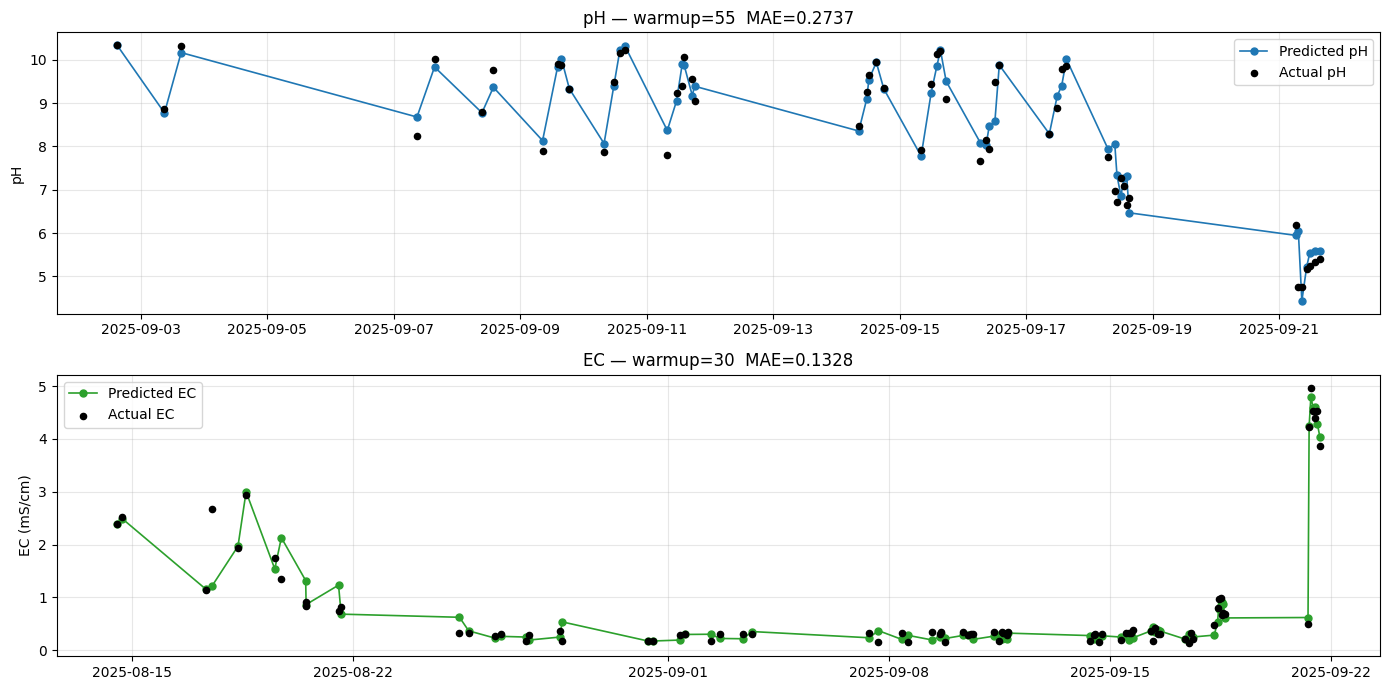

In [8]:
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=False)

axes[0].plot(res_ph.index, res_ph['ph_pred'], 'o-', color='tab:blue', ms=5, lw=1.2, label='Predicted pH')
axes[0].scatter(ev_ph.index, ev_ph['ph_true'], color='black', s=20, zorder=5, label='Actual pH')
axes[0].set_ylabel('pH')
axes[0].set_title(f'pH — warmup={WARMUP_PH}  MAE={m_ph["ph_mae"]:.4f}')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(res_ec.index, res_ec['ec_pred'], 'o-', color='tab:green', ms=5, lw=1.2, label='Predicted EC')
axes[1].scatter(ev_ec.index, ev_ec['ec_true'], color='black', s=20, zorder=5, label='Actual EC')
axes[1].set_ylabel('EC (mS/cm)')
axes[1].set_title(f'EC — warmup={WARMUP_EC}  MAE={m_ec["ec_mae"]:.4f}')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


pH Importance V6 (warmup=55): history importance = 0.196 (19.6%)
EC Base XGBoost Importance V6 (warmup=30): history importance = 0.017 (1.7%)


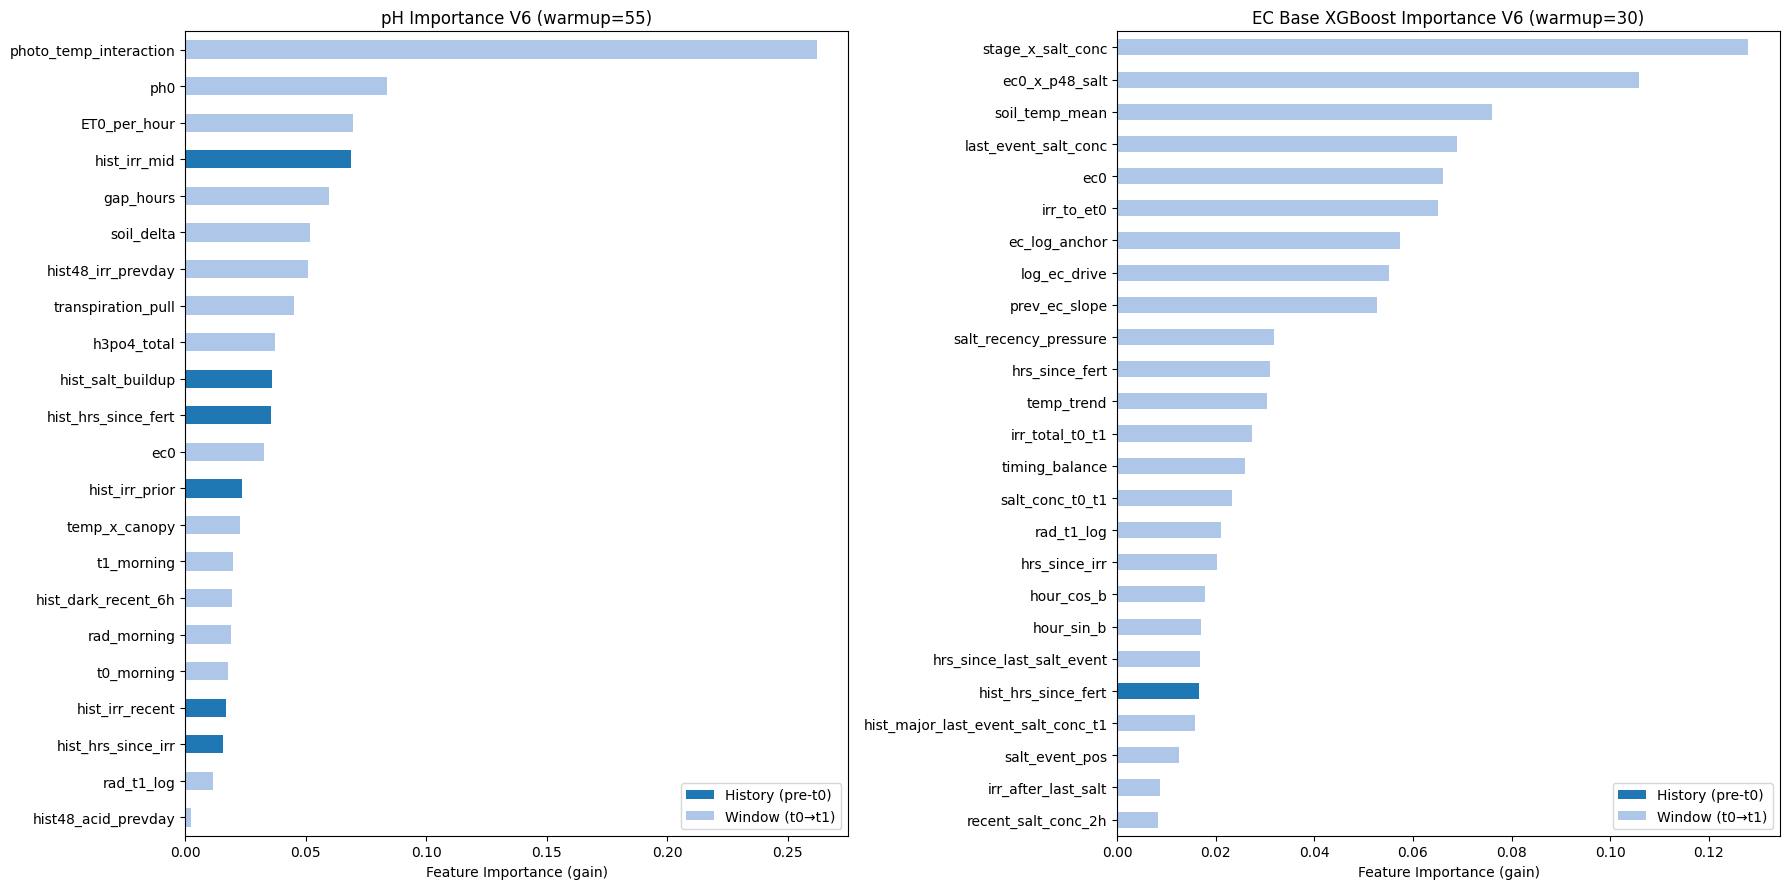

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(18, 9))

ec_importance_model = ec_model['base'] if isinstance(ec_model, dict) else ec_model

for ax, model, feat_cols, title in [
    (axes[0], ph_model, feature_cols_ph, f'pH Importance V6 (warmup={WARMUP_PH})'),
    (axes[1], ec_importance_model, feature_cols_ec, f'EC Base XGBoost Importance V6 (warmup={WARMUP_EC})'),
]:
    imp = pd.Series(model.feature_importances_, index=feat_cols).sort_values()
    colors = ['#1f77b4' if f in HIST_FEATS else '#aec7e8' for f in imp.index]
    imp.plot(kind='barh', ax=ax, color=colors)
    ax.set_title(title)
    ax.set_xlabel('Feature Importance (gain)')

    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='#1f77b4', label='History (pre-t0)'),
        Patch(facecolor='#aec7e8', label='Window (t0→t1)'),
    ]
    ax.legend(handles=legend_elements, loc='lower right')

    total_hist = sum(model.feature_importances_[i] for i, f in enumerate(feat_cols) if f in HIST_FEATS)
    print(f"{title}: history importance = {total_hist:.3f} ({total_hist*100:.1f}%)")

plt.tight_layout()
plt.show()


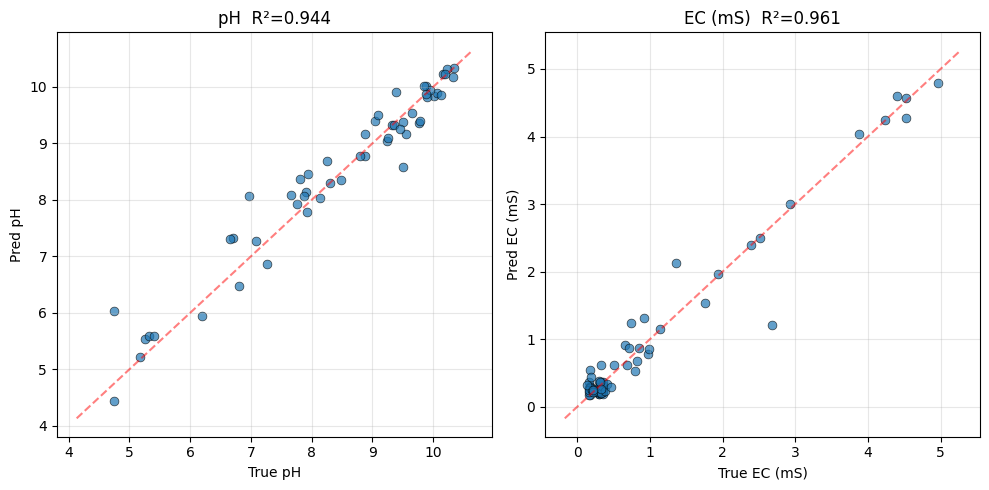

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

for ax, ev, name, tc, pc in [
    (axes[0], ev_ph, 'pH',      'ph_true', 'ph_pred'),
    (axes[1], ev_ec, 'EC (mS)', 'ec_true', 'ec_pred'),
]:
    t = ev[tc].values
    p = ev[pc].values
    ax.scatter(t, p, alpha=0.7, s=40, edgecolors='k', lw=0.5)
    lims = [min(t.min(), p.min()) - 0.3, max(t.max(), p.max()) + 0.3]
    ax.plot(lims, lims, 'r--', alpha=0.5)
    ax.set_xlabel(f'True {name}')
    ax.set_ylabel(f'Pred {name}')
    ax.set_title(f'{name}  R²={r2_score(t, p):.3f}')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


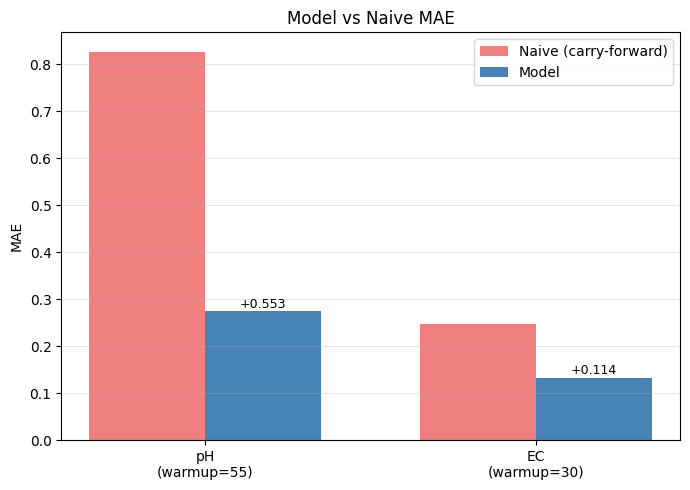

In [11]:
targets   = ['pH', 'EC']
model_mae = [m_ph['ph_mae'],       m_ec['ec_mae']]
naive_mae = [m_ph['ph_mae_naive'], m_ec['ec_mae_naive']]
warmups_used = [WARMUP_PH, WARMUP_EC]

x = np.arange(len(targets))
width = 0.35

fig, ax = plt.subplots(figsize=(7, 5))
ax.bar(x - width/2, naive_mae, width, label='Naive (carry-forward)', color='lightcoral')
ax.bar(x + width/2, model_mae, width, label='Model',                 color='steelblue')

for i, (m, n, w) in enumerate(zip(model_mae, naive_mae, warmups_used)):
    gain = n - m
    ax.text(i + width/2, m + 0.002, f'+{gain:.3f}', ha='center', va='bottom', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels([f'pH\n(warmup={WARMUP_PH})', f'EC\n(warmup={WARMUP_EC})'])
ax.set_ylabel('MAE')
ax.set_title('Model vs Naive MAE')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()


In [12]:
summary = pd.DataFrame([
    {'Target': 'pH',  'Warmup': WARMUP_PH, 'MAE': m_ph['ph_mae'],  'RMSE': m_ph['ph_rmse'],
     'Naive MAE': m_ph['ph_mae_naive'], 'Gain': m_ph['ph_gain_mae'], 'R2': m_ph['ph_r2'],  'N test': m_ph['n_test']},
    {'Target': 'EC',  'Warmup': WARMUP_EC, 'MAE': m_ec['ec_mae'],  'RMSE': m_ec['ec_rmse'],
     'Naive MAE': m_ec['ec_mae_naive'], 'Gain': m_ec['ec_gain_mae'], 'R2': m_ec['ec_r2'],  'N test': m_ec['n_test']},
])
summary = summary.set_index('Target')
print(summary.to_string())


        Warmup       MAE      RMSE  Naive MAE      Gain        R2  N test
Target                                                                   
pH          55  0.273732  0.379378   0.826667  0.552935  0.943939      54
EC          30  0.132828  0.234350   0.246735  0.113907  0.960677      79


In [13]:
import os
os.makedirs('exports', exist_ok=True)

EXPORT_PREFIX = 'v8_24h'

ev_ph[['ph_true','ph_pred','ph_naive','gap_hours']].to_csv(f'exports/{EXPORT_PREFIX}_eval_ph.csv')
ev_ec[['ec_true','ec_pred','ec_naive','gap_hours']].to_csv(f'exports/{EXPORT_PREFIX}_eval_ec.csv')

ph_pred_cols = [c for c in ['ph_pred','gap_hours'] if c in res_ph.columns]
ec_pred_cols = [c for c in ['ec_pred','gap_hours'] if c in res_ec.columns]
res_ph[ph_pred_cols].to_csv(f'exports/{EXPORT_PREFIX}_pred_ph.csv')
res_ec[ec_pred_cols].to_csv(f'exports/{EXPORT_PREFIX}_pred_ec.csv')

fi_ph = pd.Series(ph_model.feature_importances_, index=feature_cols_ph).sort_values(ascending=False)
ec_importance_model = ec_model['base'] if isinstance(ec_model, dict) else ec_model
fi_ec = pd.Series(ec_importance_model.feature_importances_, index=feature_cols_ec).sort_values(ascending=False)
fi_ph.to_csv(f'exports/{EXPORT_PREFIX}_fi_ph.csv', header=['importance'])
fi_ec.to_csv(f'exports/{EXPORT_PREFIX}_fi_ec.csv', header=['importance'])
if isinstance(ec_model, dict) and ec_model.get('specialist') is not None:
    specialist_reg = ec_model['specialist'].named_steps['huberregressor']
    fi_ec_specialist = pd.Series(specialist_reg.coef_, index=feature_cols_ec_specialist).sort_values(key=np.abs, ascending=False)
    fi_ec_specialist.to_csv(f'exports/{EXPORT_PREFIX}_fi_ec_specialist_coefficients.csv', header=['coefficient'])

pd.DataFrame({'timestamp': list(ev_ph.index),
              'n_train': [WARMUP_PH + i + 1 for i in range(len(ev_ph))]}
             ).set_index('timestamp').to_csv(f'exports/{EXPORT_PREFIX}_train_sizes_ph.csv')
pd.DataFrame({'timestamp': list(ev_ec.index),
              'n_train': [WARMUP_EC + i + 1 for i in range(len(ev_ec))]}
             ).set_index('timestamp').to_csv(f'exports/{EXPORT_PREFIX}_train_sizes_ec.csv')

print(f"{EXPORT_PREFIX} exports done - files written to exports/")
print(f"  {EXPORT_PREFIX}_eval_ph.csv        {len(ev_ph)} rows")
print(f"  {EXPORT_PREFIX}_eval_ec.csv        {len(ev_ec)} rows")
print(f"  {EXPORT_PREFIX}_pred_ph.csv        {len(res_ph)} rows")
print(f"  {EXPORT_PREFIX}_pred_ec.csv        {len(res_ec)} rows")
print(f"  {EXPORT_PREFIX}_fi_ph.csv          {len(fi_ph)} features")
print(f"  {EXPORT_PREFIX}_fi_ec.csv          {len(fi_ec)} features")


v8_24h exports done - files written to exports/
  v8_24h_eval_ph.csv        54 rows
  v8_24h_eval_ec.csv        79 rows
  v8_24h_pred_ph.csv        54 rows
  v8_24h_pred_ec.csv        79 rows
  v8_24h_fi_ph.csv          22 features
  v8_24h_fi_ec.csv          25 features
